In [1]:
import pandas as pd
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import calibration as cal

In [11]:
raw1 = cal.read_calib_csv('calib_pos1.csv')

Scanline 0, Channel A: Calibration Point = 1054, Depth = 0.0155992
Scanline 0, Channel B: Calibration Point = 1049, Depth = 0.0155252
Scanline 0, Channel C: Calibration Point = 1094, Depth = 0.0161912
Scanline 0, Channel D: Calibration Point = 1089, Depth = 0.0161172
Scanline 0, Channel E: Calibration Point = 1130, Depth = 0.016724
Scanline 0, Channel F: Calibration Point = 1124, Depth = 0.016635200000000003
Scanline 0, Channel G: Calibration Point = 1041, Depth = 0.0154068
Scanline 0, Channel H: Calibration Point = 797, Depth = 0.0117956
Scanline 1, Channel A: Calibration Point = 1063, Depth = 0.0157324
Scanline 1, Channel B: Calibration Point = 1031, Depth = 0.0152588
Scanline 1, Channel C: Calibration Point = 1074, Depth = 0.0158952
Scanline 1, Channel D: Calibration Point = 1071, Depth = 0.0158508
Scanline 1, Channel E: Calibration Point = 1110, Depth = 0.016428
Scanline 1, Channel F: Calibration Point = 1106, Depth = 0.016368800000000003
Scanline 1, Channel G: Calibration Point = 

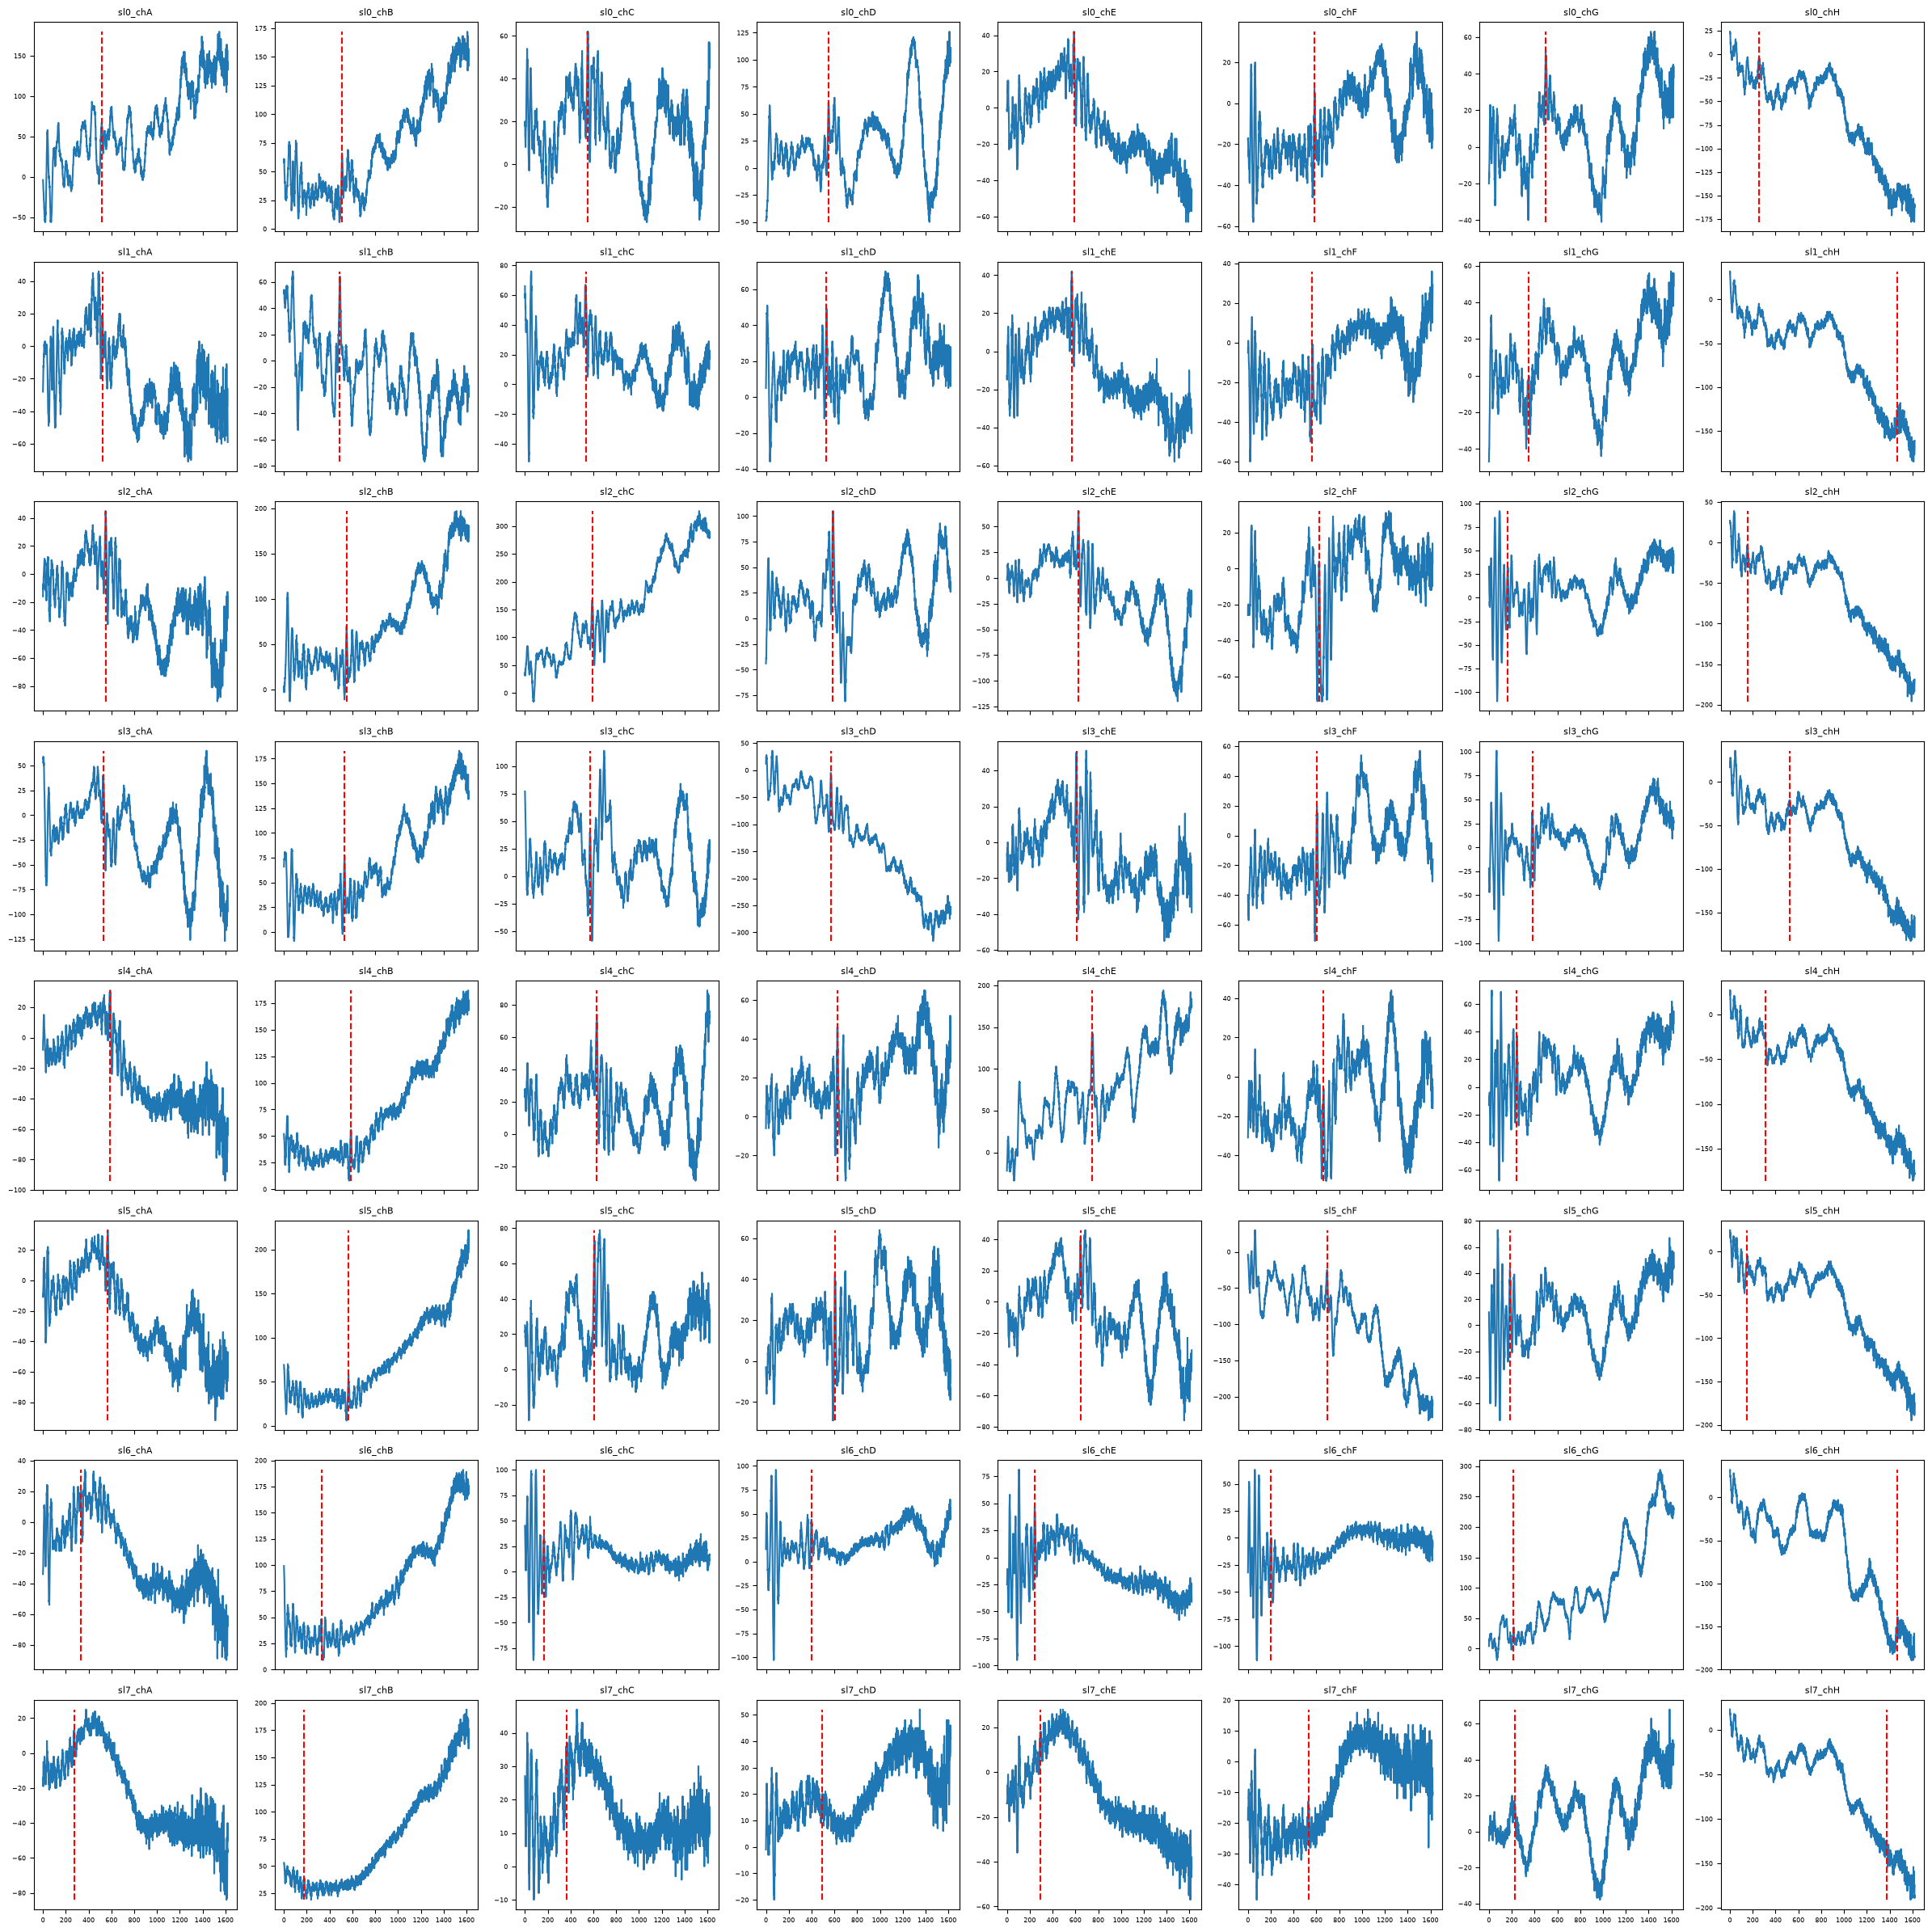

In [3]:

# to_plot = envelope(filter_fft(raw_data))
# to_plot = filter_fft(raw_data)
def plot_calib_points(to_plot):
    points = cal.find_calib_points(to_plot)

    start_idx = cal.depth_to_index(cal.MIN_DEPTH)
    end_idx = cal.depth_to_index(cal.MAX_DEPTH)
    fig, axes = plt.subplots(8, 8, figsize=(24, 24), sharex=True)
    for scanline in range(8):
        for channel in range(8):
            ax = axes[scanline, channel]
            wave = to_plot[scanline, channel, :]
            window = np.array(wave[start_idx:end_idx])
            maxidx = int(points[scanline, channel]) - start_idx
            ax.plot(window)
            ax.plot([maxidx, maxidx], [window.min(), window.max()], 'r--')
            ax.set_title(f'sl{scanline}_ch{chr(ord("A")+channel)}', fontsize=8)
            ax.tick_params(labelsize=6)
    fig.tight_layout()
    plt.show()


plot_calib_points(raw1)

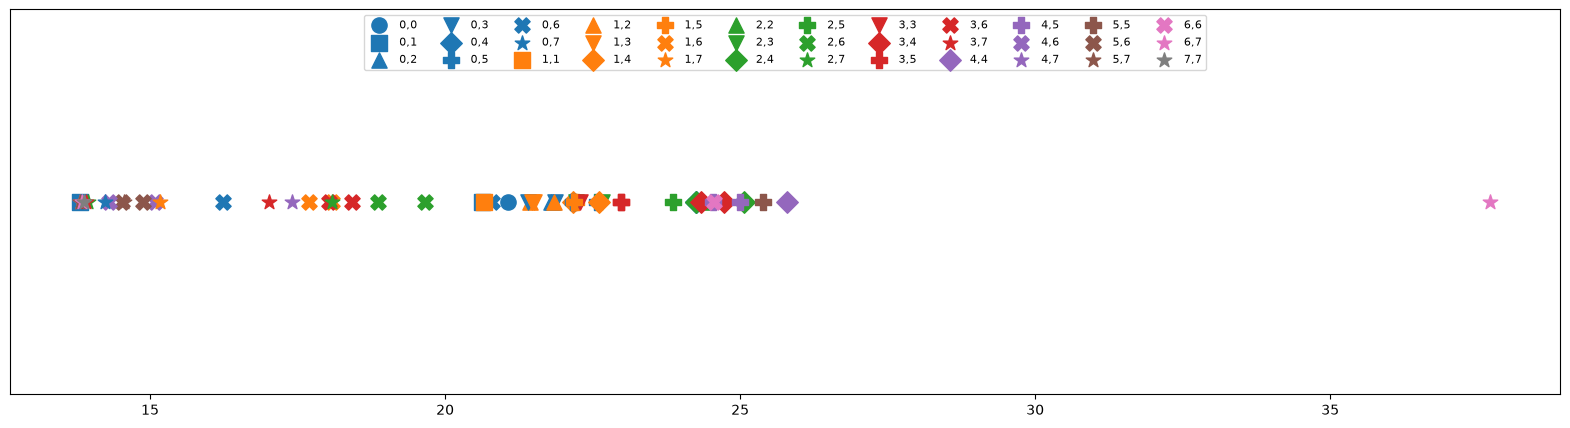

In [17]:
def plot_dist_ests(points):
    plt.figure(figsize=(20, 5))
    # style keyed on the unordered pair {i, j}: color = min(i,j), marker = max(i,j),
    # so (1,2) and (2,1) render identically
    markers = ['o', 's', '^', 'v', 'D', 'P', 'X', '*']
    colors = plt.cm.tab10.colors
    seen = set()
    for i in range(8):
        for j in range(8):
            lo, hi = min(i, j), max(i, j)
            label = f'{lo},{hi}'
            plt.scatter(points[i, j], 0, color=colors[lo], marker=markers[hi], s=120,
                        label=None if label in seen else label)
            seen.add(label)
    plt.yticks([])
    plt.legend(ncol=12, fontsize=8, loc='upper center')
    plt.show()

plot_dist_ests(cal.find_calib_time(raw1) * 1e6)

Scanline 0, Channel A: Calibration Point = 1054, Depth = 0.0155992
Scanline 0, Channel B: Calibration Point = 1049, Depth = 0.0155252
Scanline 0, Channel C: Calibration Point = 1094, Depth = 0.0161912
Scanline 0, Channel D: Calibration Point = 1089, Depth = 0.0161172
Scanline 0, Channel E: Calibration Point = 1130, Depth = 0.016724
Scanline 0, Channel F: Calibration Point = 1124, Depth = 0.016635200000000003
Scanline 0, Channel G: Calibration Point = 1041, Depth = 0.0154068
Scanline 0, Channel H: Calibration Point = 797, Depth = 0.0117956
Scanline 1, Channel A: Calibration Point = 1063, Depth = 0.0157324
Scanline 1, Channel B: Calibration Point = 1031, Depth = 0.0152588
Scanline 1, Channel C: Calibration Point = 1074, Depth = 0.0158952
Scanline 1, Channel D: Calibration Point = 1071, Depth = 0.0158508
Scanline 1, Channel E: Calibration Point = 1110, Depth = 0.016428
Scanline 1, Channel F: Calibration Point = 1106, Depth = 0.016368800000000003
Scanline 1, Channel G: Calibration Point = 

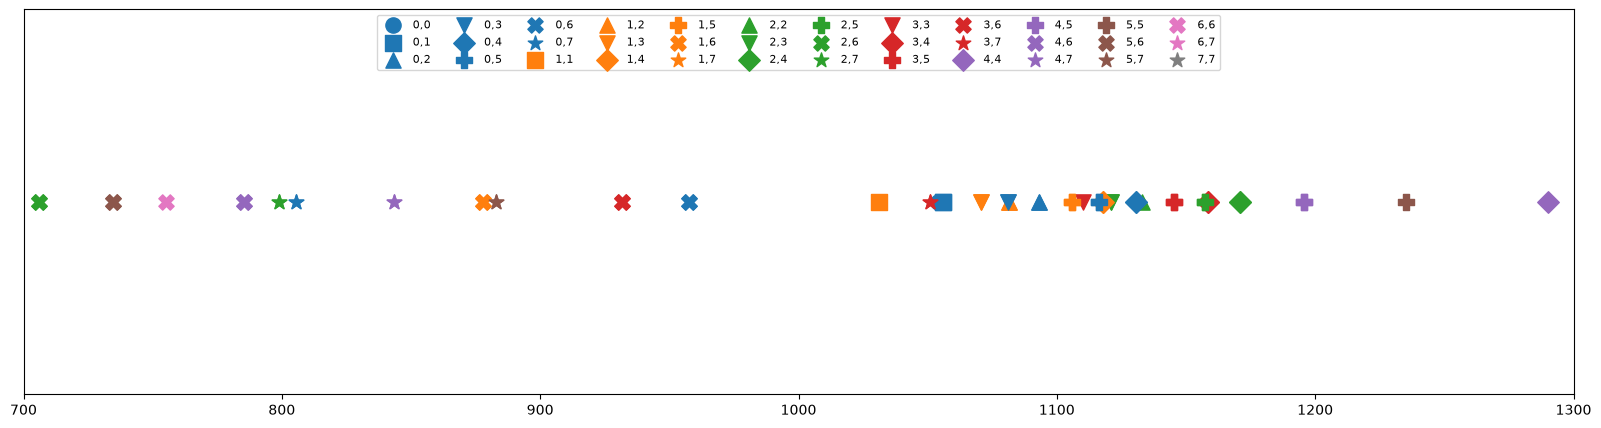

In [ ]:

points = cal.find_calib_dists(raw1)
depth_ests = (points + points.T) / 2

plot_dist_ests(depth_ests)

In [14]:
import importlib
importlib.reload(cal)

import glob

# input = [cal.read_calib_csv(f'calib_pos{n + 1}.csv') for n in range(7)]
input = [cal.read_calib_csv(n) for n in glob.glob('array_*.csv')]
k = len(input)
r = cal.solve(input)

172 / 448 errored measurements
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)
(8, 8, 7)


In [15]:
wire_pos = r.x[7:7+2*k] * 1e3

est_pitch = 20e-3 / 112
chan_offsets = np.concatenate([[0], r.x[0:7]])
tau = r.x[7+2*k:7+2*k+8]
speed = r.x[7+2*k+8]

wire_pos, chan_offsets / est_pitch, tau, speed


final_calib = np.concatenate([chan_offsets.reshape((8, 1)), tau.reshape((8, 1))], axis=1)
np.savetxt("calibration.csv", final_calib, delimiter=",")

In [10]:
chan_offsets

array([0.00598618, 0.001641  , 0.00609061, 0.0074988 , 0.00823829,
       0.00985504, 0.01014614])

In [13]:
tau

array([1.00502291e-05, 9.69896862e-06, 6.42186411e-06, 7.68458939e-06,
       7.64330733e-06, 7.08072535e-06, 7.47738040e-06, 6.64919250e-06])